In [ ]:
import torch
import ultralytics
import cv2
import os
import json
from ultralytics import YOLO  
from pathlib import Path
from joblib import load
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import joblib
from joblib import dump

## Distance

In [3]:
import pandas as pd
import re
import os

def parse_filename(filename):
    """
    Extrait l'angle (float), la distance (float) et la personne (int) du nom de fichier
    au format 'angle-distance-Px.txt', où angle et distance peuvent être décimaux.
    """
    match = re.match(r'([\d.]+)-([\d.]+)\.txt', filename)
    if match:
        angle, distance = match.groups()
        return float(angle), float(distance)
    return None, None

def load_yolo_labels_from_folder(folder_path):
    """Charge tous les fichiers YOLO d'un dossier et retourne une DataFrame avec les colonnes demandées."""
    column_names = ["x",	"y",	"w",	"h",	"Cx",	"Cy",	"W",	"H",	"distance",	"angle",	"x_center",	"y2","y_low"]
    
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            angle, distance = parse_filename(filename)
            
            with open(filepath, 'r') as file:
                for line in file:
                    values = list(map(float, line.split()))
                    if len(values) >= 5:  # YOLO format : class x_center y_center width height
                        _, x, y, width, height = values[:5]  # On ignore class_id
                        cx = x * 5376
                        cy= y * 2688
                        cwidth = width * 5376
                        cheight = height * 2688
                        x_center = cx - 5376 / 2
                        low_y = 2688-(cy + cheight / 2)
                        y_low=y-height/2
                        distance=distance
                   
                        
                        row = [x,y,width,height,cx,cy,cwidth,cheight,distance,angle,x_center,low_y,y_low]
                        data.append(row)

    return pd.DataFrame(data, columns=column_names)


# Exemple d'utilisation
second_exp= load_yolo_labels_from_folder("/Users/martin.dejaeghere/Position_Estimation/bikes/labels-studio")
second_exp=second_exp.loc[second_exp['distance'] <= 2400]

thredshold_dist=1000

second_exp_big= second_exp.loc[second_exp['distance'] >= thredshold_dist]
second_exp_small= second_exp.loc[second_exp['distance'] <= thredshold_dist]



def compute_angle_from_normalized_bbox(x_center_norm, image_width):
    """
    Converts a normalized x_center to relative angle in degrees
    """
   
    angle_raw = (x_center_norm / image_width) * 360
    relative_angle = (angle_raw) % 360

    if relative_angle > 180:
        relative_angle -= 360

    return relative_angle


second_exp['angle_calculated'] = second_exp['x_center'].apply(lambda x: compute_angle_from_normalized_bbox(x, 5376))





In [4]:
second_exp.to_csv('bike_data.csv', index=False)

Split 1: 12/48 = 0.250
Split 2: 12/48 = 0.250
Split 3: 12/48 = 0.250
Split 4: 12/48 = 0.250
Split 5: 12/48 = 0.250
Split 6: 12/48 = 0.250
Split 7: 12/48 = 0.250
Split 8: 12/48 = 0.250
Split 9: 12/48 = 0.250
Split 10: 12/48 = 0.250
0.3188851943681611 123.79451977658937
-0.03830108587583392 101.89706010851509
-0.9911598671703254 141.10846420999434
0.980855496738055 41.50909892511576
0.4869471160235693 179.0692749986075
0.8456600375380453 78.57225018082521
0.45809939740784855 110.42084748055237
0.8159376409191803 171.60995732454205
0.4869471160235693 179.0692749986075
0.7244286270861691 183.73212343502777
Ordre 1: R² moyen = 0.4088, RMSE moyen = 131.08
0.716837599996502 79.81950889399599
0.35325091519096086 80.42071156170151
0.5120552846890049 69.85303968411075
0.9415432247369456 72.53350793719339
0.8051275980513539 110.36088583275499
0.8056393618630542 88.17270283640984
0.909109505029155 45.222075768854445
0.9245691205454984 109.85873070776054
0.8051275980513539 110.36088583275499
0.9079

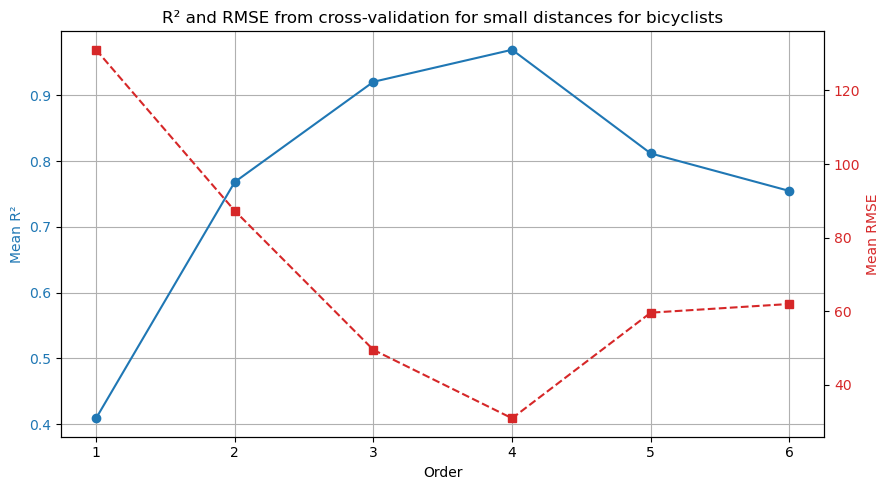

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# (Assuming second_exp_small is already defined)

 
# (Assuming second_exp_small is already defined)
# Définir 10 paires de distances pour les splits
dist_pairs = [
    [300, 600],
    [200, 400],
    [600, 400],
    [800, 200],
    [500, 1000],
    [200, 600],
    [400, 700],
    [1000, 200],
    [1000, 500],
    [1000, 300]
]
splits = []

for pair in dist_pairs:
    test_data = second_exp_small.loc[second_exp_small['distance'].isin(pair)]
    training_data = second_exp_small.loc[~second_exp_small['distance'].isin(pair)]
    splits.append((training_data, test_data))

# Vérifier les ratios test/train
for i, (train, test) in enumerate(splits, 1):
    print(f"Split {i}: {len(test)}/{len(train)} = {len(test)/len(train):.3f}")
# Évaluation
def evaluate_polynomial_regression(splits, order):
    r2_dist_scores, rmse_scores = [], []

    for training_data_small, test_data_small in splits:
        X_train = training_data_small[["x_center", "y2"]].astype(int).values
        y_dist_train = training_data_small["distance"].round(1).values.flatten()

        X_test = test_data_small[["x_center", "y2"]].astype(int).values
        y_dist_test = test_data_small["distance"].round(1).values.flatten()

        poly = PolynomialFeatures(degree=order)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_dist = LinearRegression().fit(X_train_poly, y_dist_train)
        y_dist_pred = model_dist.predict(X_test_poly)

        r2_dist = r2_score(y_dist_test, y_dist_pred)
        rmse = np.sqrt(mean_squared_error(y_dist_test, y_dist_pred))

        r2_dist_scores.append(r2_dist)
        rmse_scores.append(rmse)
        print(r2_dist, rmse)
    return np.mean(r2_dist_scores), np.mean(rmse_scores)

# Itération sur les ordres
orders = range(1,7)
r2_values = []
rmse_values = []

for order in orders:
    r2_moyen, rmse_moyen = evaluate_polynomial_regression(splits, order)
    r2_values.append(r2_moyen)
    rmse_values.append(rmse_moyen)
    print(f"Ordre {order}: R² moyen = {r2_moyen:.4f}, RMSE moyen = {rmse_moyen:.2f}")

best_degree_small_dist = orders[np.argmax(r2_values)]

# Affichage du graphique
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel("Order")
ax1.set_ylabel("Mean R²", color=color)
ax1.plot(orders, r2_values, marker='o', color=color, label='R² mean')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Second y-axis for RMSE
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Mean RMSE", color=color)
ax2.plot(orders, rmse_values, marker='s', linestyle='--', color=color, label='RMSE mean')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("R² and RMSE from cross-validation for small distances for bicyclists")
fig.tight_layout()
plt.show()


Split 1: 10/35 = 0.286
Split 2: 10/35 = 0.286
Split 3: 10/35 = 0.286
Split 4: 10/36 = 0.278
Split 5: 10/35 = 0.286
Split 6: 10/36 = 0.278
Split 7: 10/35 = 0.286
Split 8: 10/35 = 0.286
Split 9: 10/35 = 0.286
Split 10: 10/35 = 0.286
0.9778348732976019 58.348637186213224
0.5039587348731367 140.8603940256967
0.9226709875769772 83.42428374323661
0.06094044904099494 189.89440949334394
0.804942768566656 129.81889229168812
0.8401770611704049 274.1910108399645
0.7748257984664731 94.90504760728521
0.5830432533614025 129.14437605077467
0.8434309832130737 118.70640888689776
0.5456772060274946 269.613885094223
Ordre 1: R² moyen = 0.6858, RMSE moyen = 148.89
0.9679078178180919 70.20939526260773
0.9212247920795741 56.13384288303301
0.9610025111400216 59.24334559592376
0.7305359466560843 101.72226722014389
0.964663925632031 55.25429237075188
0.9616039433630326 134.39309893751786
0.9470738147376758 46.011383488143096
0.9159493005501465 57.98299731812888
0.9512603025226467 66.23120694175665
0.9075863358

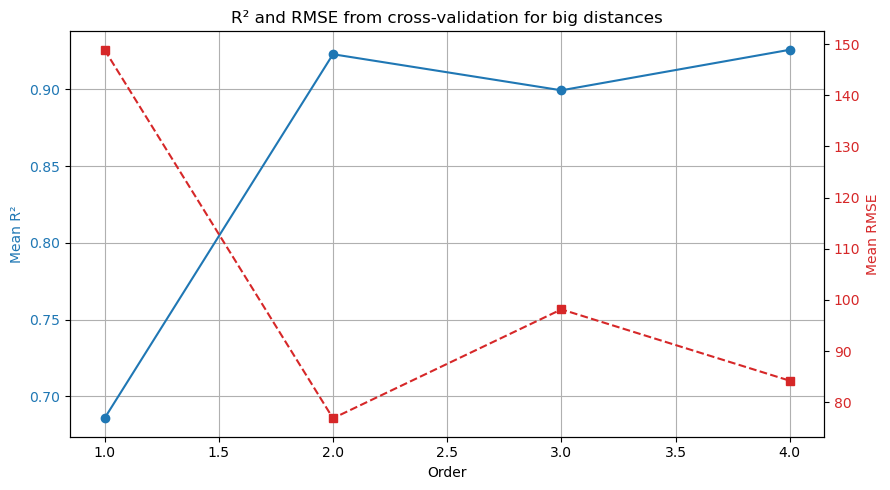

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Définir les 10 splits

dist_pairs = [
    [1200, 2000],
    [1800, 1400],
    [1200, 1800],
    [2000, 2400],
    [1600, 2200],
    [1000, 2400],
    [1800, 2200],
    [1200, 1600],
    [1400, 2000],
    [1000, 1800]
]


splits = []

for pair in dist_pairs:
    test_data = second_exp_big.loc[second_exp_big['distance'].isin(pair)].head(10)
    training_data = second_exp_big.loc[~second_exp_big['distance'].isin(pair)]
    splits.append((training_data, test_data))

# Vérifier les ratios test/train
for i, (train, test) in enumerate(splits, 1):
    print(f"Split {i}: {len(test)}/{len(train)} = {len(test)/len(train):.3f}")

# Évaluation
def evaluate_polynomial_regression(splits, order):
    r2_dist_scores, rmse_scores = [], []

    for training_data_small, test_data_small in splits:
        X_train = training_data_small[["y2","x_center"]].astype(int).values
        y_dist_train = training_data_small["distance"].round(1).values.flatten()

        X_test = test_data_small[[ "y2","x_center"]].astype(int).values
        y_dist_test = test_data_small["distance"].round(1).values.flatten()

        poly = PolynomialFeatures(degree=order)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_dist = LinearRegression().fit(X_train_poly, y_dist_train)
        y_dist_pred = model_dist.predict(X_test_poly)

        r2_dist = r2_score(y_dist_test, y_dist_pred)
        rmse = np.sqrt(mean_squared_error(y_dist_test, y_dist_pred))
        print(r2_dist,rmse)

        r2_dist_scores.append(r2_dist)
        rmse_scores.append(rmse)

    return np.mean(r2_dist_scores), np.mean(rmse_scores)

# Itération sur les ordres
orders = range(1, 5)
r2_values = []
rmse_values = []

for order in orders:
    r2_moyen, rmse_moyen = evaluate_polynomial_regression(splits, order)
    r2_values.append(r2_moyen)
    rmse_values.append(rmse_moyen)
    print(f"Ordre {order}: R² moyen = {r2_moyen:.4f}, RMSE moyen = {rmse_moyen:.2f}")

best_degree_big_dist = orders[np.argmin(rmse_values)]

# Affichage du graphique
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel("Order")
ax1.set_ylabel("Mean R²", color=color)
ax1.plot(orders, r2_values, marker='o', color=color, label='R² mean')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Second y-axis for RMSE
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Mean RMSE", color=color)
ax2.plot(orders, rmse_values, marker='s', linestyle='--', color=color, label='RMSE mean')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("R² and RMSE from cross-validation for big distances")
fig.tight_layout()
plt.show()


In [7]:
evaluate_polynomial_regression(splits, 2)

0.9679078178180919 70.20939526260773
0.9212247920795741 56.13384288303301
0.9610025111400216 59.24334559592376
0.9679078178180919 70.20939526260773
0.964663925632031 55.25429237075188
0.9616039433630326 134.39309893751786
0.9470738147376758 46.011383488143096
0.9159493005501465 57.98299731812888
0.9512603025226467 66.23120694175665
0.9075863358886178 121.59846322146159


(0.946618056154993, 73.72674212819322)

## Cross-validation angle

In [8]:
calibration_values_angle = pd.DataFrame(second_exp[["x_center"]]).astype(int)
angle_values_angle = pd.DataFrame(second_exp["angle"]).round(1)
distance_values_angle = pd.DataFrame(second_exp["distance"]).round(1)


calibration_values_angle = calibration_values_angle.astype(float)
angle_values_angle = angle_values_angle.astype(float)


Ordre 1: R² moyen = 0.9685, RMSE moyen = 2.25
Ordre 2: R² moyen = 0.9655, RMSE moyen = 2.60
Ordre 3: R² moyen = 0.8562, RMSE moyen = 4.02
Ordre 4: R² moyen = 0.3116, RMSE moyen = 10.91
Ordre 5: R² moyen = -0.9923, RMSE moyen = 22.28


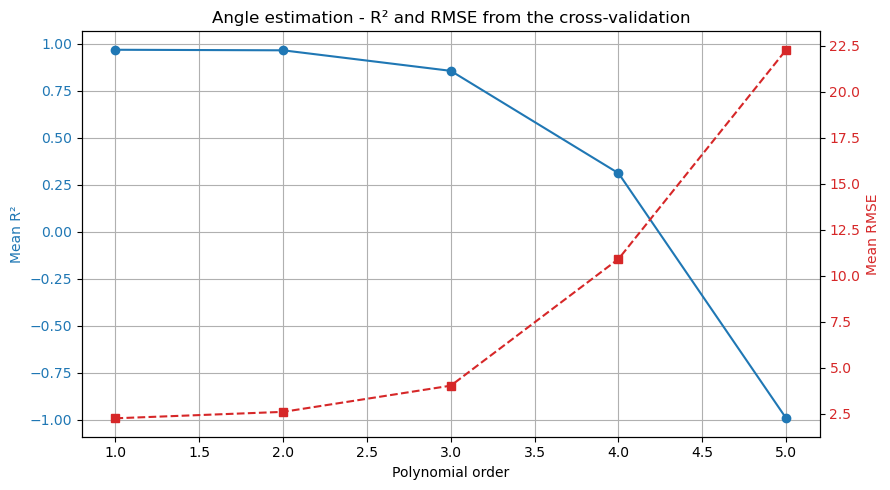

In [9]:
import numpy as np
import pandas as pd

# Exemple : construire un DataFrame de base
df = pd.DataFrame(calibration_values_angle, columns=["x_center", "y2"])
df["angle"] = angle_values_angle['angle'] if hasattr(angle_values_angle, 'columns') else angle_values_angle

# Définir les splits selon des sous-ensembles d’angles
test_angles_sets = [
    [90, 45],
    [15, 60],
    [30, 75],
    [30,45],
    [15, 45]
]

splits = []

for test_angles in test_angles_sets:
    test_data = df[df["angle"].isin(test_angles)]
    train_data = df[~df["angle"].isin(test_angles)]
    splits.append((train_data, test_data))

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

orders = range(1, 6)
r2_means = []
rmse_means = []

for order in orders:
    r2_list, rmse_list = [], []

    for train_data, test_data in splits:
        X_train = train_data[["x_center"]].astype(float).values
        y_train = train_data["angle"].astype(float).values

        X_test = test_data[["x_center"]].astype(float).values
        y_test = test_data["angle"].astype(float).values

        poly = PolynomialFeatures(degree=order)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression().fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        r2_list.append(r2)
        rmse_list.append(rmse)

    r2_means.append(np.mean(r2_list))
    rmse_means.append(np.mean(rmse_list))
    print(f"Ordre {order}: R² moyen = {np.mean(r2_list):.4f}, RMSE moyen = {np.mean(rmse_list):.2f}")

    # Plot R² et RMSE
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.set_xlabel("Polynomial order")
ax1.set_ylabel("Mean R²", color='tab:blue')
ax1.plot(orders, r2_means, marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel("Mean RMSE", color='tab:red')
ax2.plot(orders, rmse_means, marker='s', linestyle='--', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Angle estimation - R² and RMSE from the cross-validation")
fig.tight_layout()
plt.show()



## Model

In [10]:
second_exp_small=second_exp.loc[second_exp['distance'] <= thredshold_dist]
second_exp_big=second_exp.loc[second_exp['distance'] >= thredshold_dist]

calibration_values_small = pd.DataFrame(second_exp_small[["x_center", "y2"]]).astype(int)
angle_values_small = pd.DataFrame(second_exp_small["angle"]).round(1)
distance_values_small = pd.DataFrame(second_exp_small["distance"]).round(1)

calibration_values_big = pd.DataFrame(second_exp_big[["x_center", "y2"]]).astype(int)
angle_values_big = pd.DataFrame(second_exp_big["angle"]).round(1)
distance_values_big = pd.DataFrame(second_exp_big["distance"]).round(1)

calibration_values = pd.DataFrame(second_exp[["x_center"]]).astype(int)
angle_values = pd.DataFrame(second_exp["angle"]).round(1)
distance_values = pd.DataFrame(second_exp["distance"]).round(1)


In [11]:
import matplotlib.pyplot as plt
import numpy as np

dist_pr = PolynomialFeatures(degree=best_degree_small_dist)

x_train_pr = dist_pr.fit_transform(calibration_values_small)


# Fitting the polynomial equation for the distance
poly_dist = LinearRegression()
poly_dist.fit(x_train_pr, distance_values_small)

# Sauvegarde du modèle de distance
joblib.dump((dist_pr, poly_dist), 'distance_predictor_small.joblib')





# Fit a model of order 4 for angle
angle_pr = PolynomialFeatures(degree=1)

x_train_pr = angle_pr.fit_transform(calibration_values)


# Fitting the polynomial equation for the angles
poly_angular = LinearRegression()
poly_angular.fit(x_train_pr, angle_values)
# Sauvegarde du modèle d'angle
joblib.dump((angle_pr, poly_angular), 'angle_predictor.joblib')
dist_pr = PolynomialFeatures(degree=2)

x_train_pr = dist_pr.fit_transform(calibration_values_big)

# Fitting the polynomial equation for the distance
poly_dist = LinearRegression()
poly_dist.fit(x_train_pr, distance_values_big)


# Sauvegarde du modèle de distance
joblib.dump((dist_pr, poly_dist), 'distance_predictor_big.joblib')





['distance_predictor_big.joblib']

In [12]:
import joblib
def dist_est(c_x, c_y,h):
    distance_features, distance_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/bikes/distance_predictor_small.joblib')
    image_data =pd.DataFrame([[c_x, c_y]], columns=["x_center", "y2"])
    cur_dist = distance_model.predict(distance_features.transform(image_data))[0][0]
    if cur_dist >thredshold_dist:
        distance_features, distance_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/bikes/distance_predictor_big.joblib')
        image_data =pd.DataFrame([[c_x, c_y,h]], columns=["x_center", "y2","H"])
        cur_dist = distance_model.predict(distance_features.transform(image_data))[0][0]
 
    return cur_dist if 0 <= cur_dist <= 3000 else float('inf')



def ang_est(c_x):
    angle_features, angle_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/bikes/angle_predictor.joblib')
    image_data =pd.DataFrame([[c_x]], columns=["x_center"])

    cur_angle = angle_model.predict(angle_features.transform(image_data))[0][0]
    return cur_angle if -10 <= cur_angle <= 100 else float('inf')

def get_ang_dist(c_x, c_y,h):
    width = 5376
    segment = width / 4  # 1344

    if 0 < c_x < segment:
        cur_dist = dist_est(c_x, c_y,h)
        cur_ang = ang_est(c_x)

    elif segment <= c_x < 2 * segment:
        c_x -= segment
        cur_dist = dist_est(c_x, c_y,h)
        cur_ang = ang_est(c_x)
        cur_ang += 90



    elif -segment < c_x < 0:
        c_x = -c_x
        cur_dist = dist_est(c_x, c_y,h)
        cur_ang = ang_est(c_x)
        cur_ang = -cur_ang

    elif -2 * segment < c_x <= -segment:
        c_x = -c_x - segment
        cur_dist = dist_est(c_x, c_y,h)
        cur_ang = ang_est(c_x)
        cur_ang = -cur_ang - 90

 

    else:
        cur_dist = float('inf')
        cur_ang = float('inf')

    return cur_ang, cur_dist


# Change this and check if the output is correct:
c_x =108
c_y = 1262
h=56
cur_angle,cur_dist = get_ang_dist(c_x, c_y,h)

print(f"Distance: {cur_dist}")
print(f"Angle: {cur_angle}")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- H


## Validation

In [ ]:
model = YOLO("/Users/martin.dejaeghere/Library/CloudStorage/OneDrive-Chalmers/Fichiers de Marco Dozza - MicroSINT/03 - Models/Road-user identification/MicroVision-Chalmers-x-20250304.pt")
# Définir les classes (dans le même ordre que lors de l'entraînement)
classes = ["pedestrians", "bikes", "bicyclists", "e-scooters", "e-scooterists"]

# Dossier contenant les images
image_dir = "/Users/martin.dejaeghere/Position_Estimation/bikes/validation/images"
output_images_dir = "validation/output_images"
output_labels_dir = "validation/output_labels"
os.makedirs(output_images_dir, exist_ok=True)
os.makedirs(output_labels_dir, exist_ok=True)

# Traiter chaque image dans le dossier
for image_name in os.listdir(image_dir):
    image_path = os.path.join(image_dir, image_name)
    image = cv2.imread(image_path)
    if image is None:
        continue  # Ignorer les fichiers non valides

    # Exécuter la détection YOLO
    results = model.predict(image, iou=0.45, imgsz=1280, conf=0.3,classes=2)
    
    # Annoter l'image
    annotated_image = results[0].plot()
    
    # Sauvegarder l'image annotée
    output_image_path = os.path.join(output_images_dir, image_name)
    cv2.imwrite(output_image_path, annotated_image)
    
    # Sauvegarder les labels au format YOLO
    label_filename = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(output_labels_dir, label_filename)
    with open(label_path, "w") as f:
        for r in results[0].boxes:
            cls = int(r.cls)
            x_center, y_center, w, h = r.xywhn[0]  # Coordonnées normalisées
            #f.write(f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")


0: 640x1280 1 cyclist, 837.1ms
Speed: 4.7ms preprocess, 837.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 cyclist, 793.5ms
Speed: 3.2ms preprocess, 793.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 cyclist, 766.5ms
Speed: 3.6ms preprocess, 766.5ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 2 cyclists, 779.9ms
Speed: 3.5ms preprocess, 779.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 cyclist, 770.8ms
Speed: 3.5ms preprocess, 770.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 cyclist, 754.7ms
Speed: 3.2ms preprocess, 754.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 cyclist, 825.7ms
Speed: 3.0ms preprocess, 825.7ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 cyclist, 778.1ms
Speed: 3.1ms preprocess, 778.1ms inference, 0.3ms 

In [ ]:
from math import sqrt, atan2, degrees

def parse_filename(filename):
    """
    Extrait l'angle (float), la distance (float) et la personne (int) du nom de fichier
    au format 'angle-distance-Px.txt', où angle et distance peuvent être décimaux.
    """
    match = re.match(r'([\d.]+)-([\d.]+)-V(\d+)\.txt', filename)
    if match:
        x, y, person = match.groups()
        return float(x), float(y)
    return None, None

def load_yolo_labels_from_folder(folder_path):
    """Charge tous les fichiers YOLO d'un dossier et retourne une DataFrame avec les colonnes demandées."""
    column_names = ["x",	"y",	"w",	"h",	"Cx",	"Cy",	"W",	"H",	"distance",	"angle",	"x_center",	"y2","y_low"]
    
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            x, y = parse_filename(filename)
            distance=sqrt(x**2+y**2)
            angle=degrees(atan2(x, y))
            
            with open(filepath, 'r') as file:
                for line in file:
                    values = list(map(float, line.split()))
                    if len(values) >= 5:  # YOLO format : class x_center y_center width height
                        _, x, y, width, height = values[:5]  # On ignore class_id
                        cx = x * 5376
                        cy= y * 2688
                        cwidth = width * 5376
                        cheight = height * 2688
                        x_center = cx - 5376 / 2
                        low_y = 2688-(cy + cheight / 2)
                        y_low=y-height/2
                        distance=distance*100
                   
                        
                        row = [x,y,width,height,cx,cy,cwidth,cheight,distance,angle,x_center,low_y,y_low]
                        data.append(row)

    return pd.DataFrame(data, columns=column_names)


# Exemple d'utilisation
val= load_yolo_labels_from_folder('/Users/martin.dejaeghere/Position_Estimation/bikes/validation/labels-studio')

In [ ]:
calibration_test_values=val[["x_center", "y2","H"]].astype(int)
angle_test_values=pd.DataFrame(val["angle"])
distance_test_values=pd.DataFrame(val["distance"])


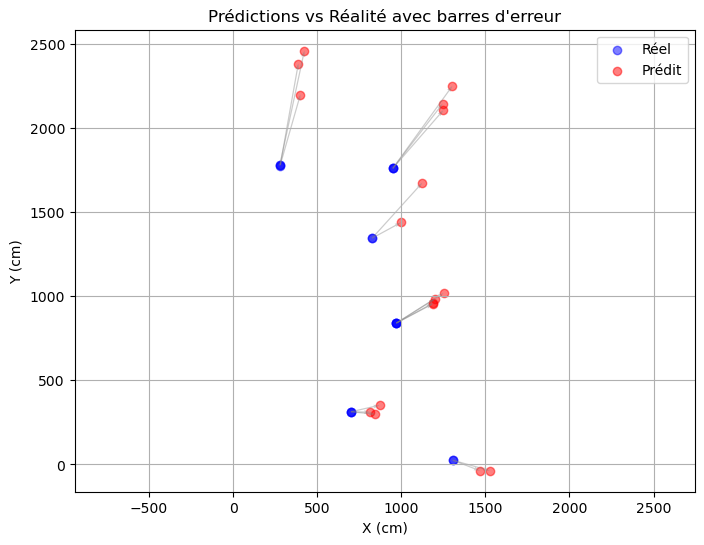

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import joblib


# Charger les modèles et les transformateurs
yhat_ang = []
yhat_dist = []

for _, row in calibration_test_values.iterrows():
    c_x, c_y,h = row["x_center"], row["y2"],row["H"]
    ang, dist = get_ang_dist(c_x, c_y,h)
    yhat_ang.append(ang)
    yhat_dist.append(dist)

# Conversion en array NumPy si besoin
yhat_ang = np.array(yhat_ang)
yhat_dist = np.array(yhat_dist)
# Valeurs réelles
true_ang = angle_test_values['angle'].values
true_dist = distance_test_values['distance'].values

# Conversion polaire -> cartésienne
real_x = true_dist * np.sin(np.radians(true_ang))
real_y = true_dist * np.cos(np.radians(true_ang))

pred_x = yhat_dist * np.sin(np.radians(yhat_ang))
pred_y = yhat_dist * np.cos(np.radians(yhat_ang))

# Vecteurs d'erreur (flèches de réel → prédit)
dx = pred_x - real_x
dy = pred_y - real_y

# Tracer les points et les barres d'erreur
plt.figure(figsize=(8, 6))
plt.scatter(real_x, real_y, c='blue', label='Réel', alpha=0.5)
plt.scatter(pred_x, pred_y, c='red', label='Prédit', alpha=0.5)
plt.quiver(real_x, real_y, dx, dy, angles='xy', scale_units='xy', scale=1, color='gray', alpha=0.4, width=0.002)

plt.axis('equal')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title("Prédictions vs Réalité avec barres d'erreur")
plt.legend()
plt.grid(True)
plt.show()



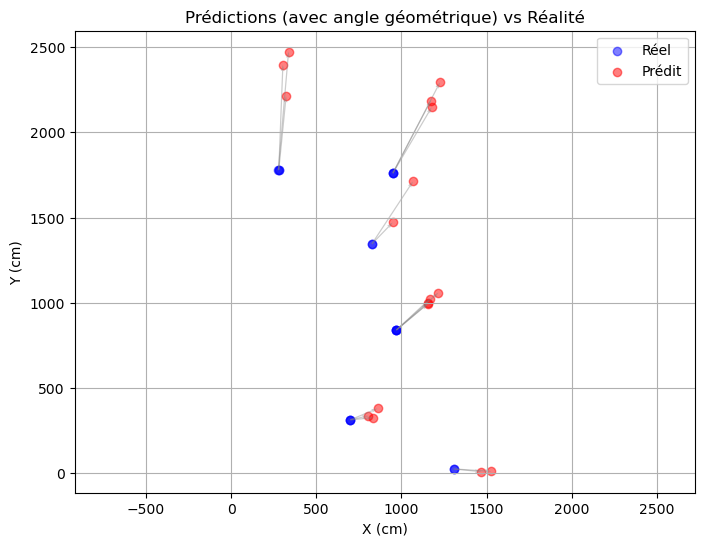

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures




yhat_ang = []
yhat_dist = []

for _, row in calibration_test_values.iterrows():
    c_x, c_y,h = row["x_center"], row["y2"],row["H"]
    ang, dist = get_ang_dist(c_x, c_y,h)
    yhat_ang.append(ang)
    yhat_dist.append(dist)

# Conversion en array NumPy si besoin
yhat_dist = np.array(yhat_dist)

# Remplacer la prédiction angulaire par le calcul depuis Xc
image_width = 5376  
Xc_test = calibration_test_values['x_center'].values
yhat_ang = np.array([compute_angle_from_normalized_bbox(x, image_width) for x in Xc_test])

# Valeurs réelles
true_ang = angle_test_values['angle'].values
true_dist = distance_test_values['distance'].values

real_x = true_dist * np.sin(np.radians(true_ang))
real_y = true_dist * np.cos(np.radians(true_ang))

pred_x = yhat_dist * np.sin(np.radians(yhat_ang))
pred_y = yhat_dist * np.cos(np.radians(yhat_ang))

# Vecteurs d'erreur (flèches de réel -> prédit)
dx = pred_x - real_x
dy = pred_y - real_y

# Tracé
plt.figure(figsize=(8, 6))

plt.scatter(real_x, real_y, c='blue', label='Réel', alpha=0.5)
plt.scatter(pred_x, pred_y, c='red', label='Prédit', alpha=0.5)
plt.quiver(real_x, real_y, dx, dy, angles='xy', scale_units='xy', scale=1, color='gray', alpha=0.4, width=0.002)

plt.axis('equal')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title("Prédictions (avec angle géométrique) vs Réalité")
plt.legend()
plt.grid(True)
plt.show()


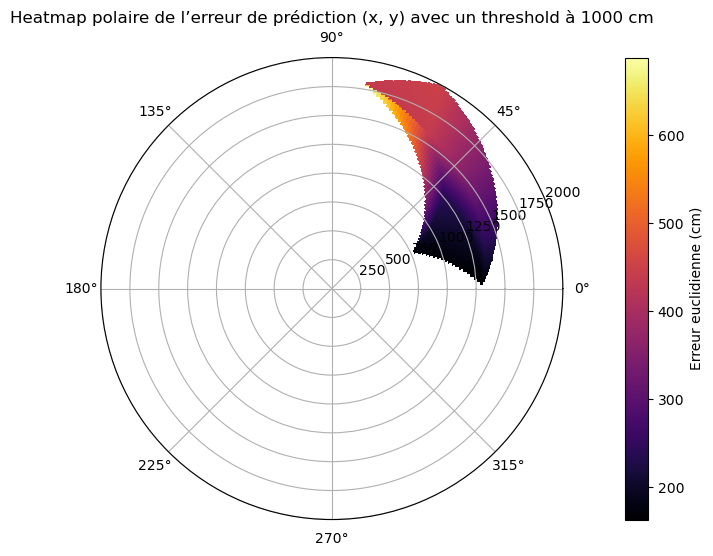

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

yhat_ang = []
yhat_dist = []

for _, row in calibration_test_values.iterrows():
    c_x, c_y,h = row["x_center"], row["y2"],row["H"]
    ang, dist = get_ang_dist(c_x, c_y,h)
    yhat_ang.append(ang)
    yhat_dist.append(dist)

# Conversion en array NumPy si besoin
yhat_ang = np.array(yhat_ang)
yhat_dist = np.array(yhat_dist)

x_vals = calibration_test_values['x_center'].values
y_vals = calibration_test_values['y2'].values
h_vals=calibration_test_values['H'].values

yhat_ang = []
yhat_dist = []

for c_x, c_y,h in zip(x_vals, y_vals,h_vals):
    ang, dist = get_ang_dist(c_x, c_y,h)
    angle=compute_angle_from_normalized_bbox(c_x, 5376)
    yhat_ang.append(angle)
    yhat_dist.append(dist)

yhat_ang = np.array(yhat_ang)
yhat_dist = np.array(yhat_dist)

true_ang = angle_test_values['angle'].values
true_dist = distance_test_values['distance'].values

# Étape 2: conversion en coordonnées cartésiennes
real_x = true_dist * np.sin(np.radians(true_ang))
real_y = true_dist * np.cos(np.radians(true_ang))
pred_x = yhat_dist * np.sin(np.radians(yhat_ang))
pred_y = yhat_dist * np.cos(np.radians(yhat_ang))

# Étape 3: calcul de l’erreur (distance euclidienne)
error = np.sqrt((real_x - pred_x)**2 + (real_y - pred_y)**2)

# Coordonnées polaires basées sur les réels (ou prédits)
theta = np.arctan2(real_y, real_x)
r = np.sqrt(real_x**2 + real_y**2)

# Étape 4: création d'une grille polaire
theta_grid, r_grid = np.meshgrid(
    np.linspace(-np.pi, np.pi, 300),
    np.linspace(min(r), max(r), 300)
)

# Interpolation des erreurs sur la grille
error_grid = griddata(
    points=(theta, r),
    values=error,
    xi=(theta_grid, r_grid),
    method='linear'
)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 6))
c = ax.pcolormesh(theta_grid, r_grid, error_grid, cmap='inferno', shading='auto')
cb = plt.colorbar(c, ax=ax, orientation='vertical', pad=0.1)
cb.set_label('Erreur euclidienne (cm)')
ax.set_title(f'Heatmap polaire de l’erreur de prédiction (x, y) avec un threshold à {thredshold_dist} cm')
plt.show()

